# graphtransport: a tour of the API

Optimal transport on graphs, in the dynamic (Benamou–Brenier) formulation of Maas and of Erbar, Rumpf,
Schmitzer & Simon. The library has four entry points:

| function | returns |
|---|---|
| `geodesic(G, rhoA, rhoB)` | the transport path between two densities |
| `transport_cost(G, rhoA, rhoB)` | the distance $W(\rho_A, \rho_B)$ |
| `barycenter(G, refs, lam)` | the weighted barycenter of reference densities |
| `analysis(G, target, refs)` | the barycentric weights that reproduce `target` |

Each takes `method=` to select `"shooting"` (the default), `"socp"` or `"sinkhorn"`. `geodesic` and
`transport_cost` also take torch tensors, and with shooting they are differentiable. Most of this notebook
runs on a 5×5 grid; it ends with timings, gradients and an image example. Running it top to bottom takes
about five minutes, most of it spent on the image example.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch

import graphtransport as gt

# The shooting solver runs many small torch operations, which gain nothing from torch's thread pool at
# these sizes but cost several times the CPU time; without this it warns once (TorchThreadsWarning).
torch.set_num_threads(1)
# torch's own notice that torch.jit is unsupported on Python 3.14+, raised inside torch.func; not ours
warnings.filterwarnings("ignore", message=".*torch.jit.script.*", category=FutureWarning)

## A graph and some densities

A `MarkovGraph` is a graph together with a reversible Markov chain on it: a rate matrix `Q` and its
stationary distribution `pi`. Constructors such as `grid_markov_chain` return the pair.

In [2]:
Q, pi = gt.grid_markov_chain(5)
G = gt.MarkovGraph(Q, pi)
G

MarkovGraph(n=25, |E|=40, mean=GeometricMean())

Densities are taken **with respect to `G.pi`**: a density `rho` satisfies `rho @ G.pi == 1`, and
the probability vector it stands for is `rho * G.pi`. We use three Gaussian bumps in three corners of
the grid, raised slightly off zero (see "Densities that touch zero" for why).

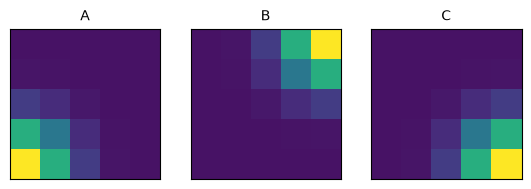

In [3]:
xy = np.array([(i % 5, i // 5) for i in range(G.n)], dtype=float)  # grid coordinates, row-major


def bump(center, width=1.0):
    rho = np.exp(-((xy - center) ** 2).sum(axis=1) / (2 * width**2)) + 0.05
    return rho / (rho @ G.pi)


A, B, C = bump((0, 0)), bump((4, 4)), bump((4, 0))


def show(densities, titles):
    fig, axes = plt.subplots(1, len(densities), figsize=(2.2 * len(densities), 2.4))
    vmax = max(float(np.max(d)) for d in densities)
    for ax, d, title in zip(np.atleast_1d(axes), densities, titles):
        ax.imshow(d.reshape(5, 5), origin="lower", cmap="viridis", vmin=0, vmax=vmax)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]), ax.set_yticks([])
    plt.show()


show([A, B, C], ["A", "B", "C"])

## Geodesics

`geodesic` returns a `GeodesicSolution`. `rho` is the path, one column per time step, and `W2` is the
squared distance. The default method integrates the flow in `nsteps` steps, so `rho` has `nsteps + 1`
columns.

W2 = 33.0372   status = converged   rho.shape = (25, 101)


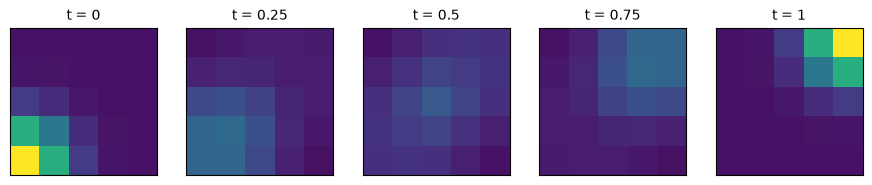

In [4]:
sol = gt.geodesic(G, A, B, nsteps=100)
print(f"W2 = {sol.W2:.4f}   status = {sol.status}   rho.shape = {sol.rho.shape}")
show([sol.rho[:, k] for k in (0, 25, 50, 75, 100)], [f"t = {k / 100:g}" for k in (0, 25, 50, 75, 100)])

The solution also carries the momenta `m` (one value per edge and time step) and the endpoint
potentials `phi0` and `phi1`, which are the gradients of $W^2$ with respect to each endpoint.

If you only need the distance, `transport_cost` returns $W$ itself (not squared). With the default
method it skips integrating the path.

In [5]:
gt.transport_cost(G, A, B)

5.747800489715504

## Choosing a method

All three methods take the same call and differ only in `method=` and its keywords:

- **`"shooting"`** (default) solves the problem exactly in time by Newton shooting on the Hamiltonian
  flow. It needs no optional dependency, but every density must be strictly positive.
- **`"socp"`** discretises time into `N` steps and solves a second-order cone program with cvxpy. It
  handles densities that are zero on part of the graph, and its error is O(1/N).
- **`"sinkhorn"`** is entropically regularised OT for a ground cost, which you pass in. It computes
  a different quantity: its `W2` is the cost under `cost=`, not the graph transport distance.

In [6]:
runs = {
    "shooting": dict(),
    "socp, N=10": dict(method="socp", N=10),
    "socp, N=40": dict(method="socp", N=40),
    "sinkhorn": dict(method="sinkhorn", cost=gt.ground_cost(G), epsilon=0.05),
}
sols = {}
for name, kw in runs.items():
    t0 = time.perf_counter()
    sols[name] = gt.geodesic(G, A, B, **kw)
    print(f"{name:12s} W2 = {sols[name].W2:8.4f}   {time.perf_counter() - t0:5.2f} s")

shooting     W2 =  33.0372    1.03 s


socp, N=10   W2 =  33.0972    0.57 s


socp, N=40   W2 =  33.0415    0.58 s
sinkhorn     W2 =   0.2608    0.02 s


The SOCP converges to shooting's value as `N` grows. Sinkhorn's number is on a different scale
(`ground_cost` normalises the squared hop distance to [0, 1]), and at time ½ its path is blurred.

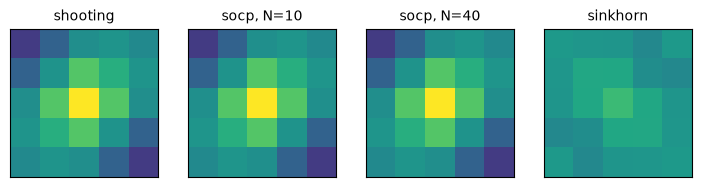

In [7]:
mid = {name: s.rho[:, s.rho.shape[1] // 2] for name, s in sols.items()}
show(list(mid.values()), list(mid.keys()))

A keyword that belongs to a different method is rejected by name, with a hint about what to use
instead:

In [8]:
try:
    gt.geodesic(G, A, B, N=10)
except TypeError as e:
    print(e)

geodesic: method='shooting' does not take N (a keyword of method='socp' and method='sinkhorn'). Shooting is exact in time; its integrator's resolution is nsteps= (default 150).


## Timing

Which method is faster depends on the data as well as the graph. Below we time one geodesic on
n×n grids for two kinds of data: near-uniform densities, and the corner-to-corner bumps used above.
Shooting runs with `fallback=False`, so a silent fallback to the SOCP can't hide in its timings.

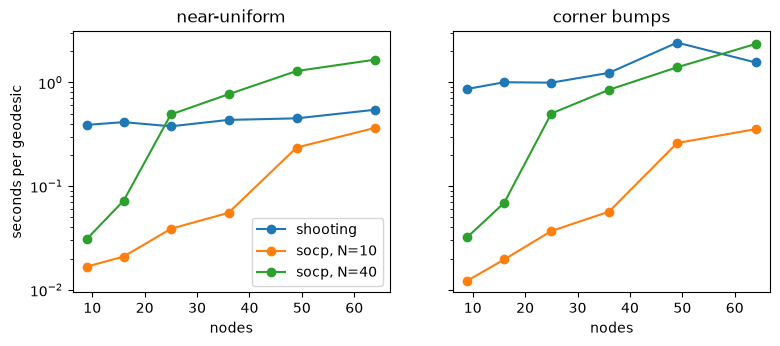

In [9]:
def grid_pair(k, kind, rng):
    Gk = gt.MarkovGraph(*gt.grid_markov_chain(k))
    if kind == "near-uniform":
        a, b = rng.uniform(0.5, 1.5, Gk.n), rng.uniform(0.5, 1.5, Gk.n)
    else:
        pts = np.array([(i % k, i // k) for i in range(Gk.n)], dtype=float)
        a = np.exp(-(pts**2).sum(axis=1) / (2 * (k / 5) ** 2)) + 0.05
        b = a[::-1].copy()  # the same bump in the opposite corner
    return Gk, a / (a @ Gk.pi), b / (b @ Gk.pi)


sizes = [3, 4, 5, 6, 7, 8]
methods = {"shooting": dict(fallback=False), "socp, N=10": dict(method="socp", N=10),
           "socp, N=40": dict(method="socp", N=40)}
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for ax, kind in zip(axes, ["near-uniform", "corner bumps"]):
    pairs = [grid_pair(k, kind, rng) for k in sizes]
    for name, kw in methods.items():
        seconds = []
        for Gk, a, b in pairs:
            t0 = time.perf_counter()
            gt.geodesic(Gk, a, b, **kw)
            seconds.append(time.perf_counter() - t0)
        ax.plot([k * k for k in sizes], seconds, "o-", label=name)
    ax.set_title(kind), ax.set_xlabel("nodes"), ax.set_yscale("log")
axes[0].set_ylabel("seconds per geodesic")
axes[0].legend()
plt.show()

On these sizes the SOCP at its default `N=10` is the fastest method for both kinds of data.
Shooting costs more when mass has to travel further. What shooting offers is fourth-order accuracy in time, no conic
solver, and gradients (below), not speed. For large graphs or long transports, pass `method="socp"`.

## Multiple shooting

Shooting solves for the initial potential by Newton's method. On a long transport the flow map bends
sharply, and Newton needs many damped steps. `segments=K` splits the time interval into K pieces and
solves for the state at every junction together: the same discrete problem, in fewer steps. The default,
`segments="auto"`, takes one ordinary step, and switches to 8 segments if the line search had to cut
that step to a quarter or less. Corner to corner on a 10×10 grid:

In [10]:
from graphtransport.shooting import log_map

G10, a10, b10 = grid_pair(10, "corner bumps", rng)
for segments in [1, "auto"]:
    t0 = time.perf_counter()
    r = log_map(G10, a10, b10, segments=segments)
    how = "single shooting" if r.starts is None else f"multiple shooting, {r.starts[0].shape[1]} segments"
    print(f"segments={segments!s:5s} W2 = {r.W2:.10f}   {r.iters:2d} Newton steps   "
          f"{time.perf_counter() - t0:4.1f} s   ({how})")

segments=1     W2 = 138.6066708191   19 Newton steps    5.0 s   (single shooting)


segments=auto  W2 = 138.6066708191    8 Newton steps    3.4 s   (multiple shooting, 8 segments)


Both give the same W2, to Newton's tolerance. On a short transport, such as near-uniform
densities, the first step is a full one, so `"auto"` stays with single shooting and costs nothing extra.

## The mean is part of the geometry

The transport metric weights each edge by a mean $\theta(\rho_x, \rho_y)$ of the densities at its two
ends. The default is `GeometricMean()`. The mean belongs to the graph rather than to each call, so every
computation on the same `G` uses the same metric. `with_mean` returns a copy of the graph with a
different mean.

In [11]:
for mean in [gt.ArithmeticMean(), gt.GeometricMean(), gt.LogarithmicMean(), gt.HarmonicMean()]:
    print(f"{mean!r:20s} W = {gt.transport_cost(G.with_mean(mean), A, B):.4f}")

ArithmeticMean()     W = 5.6483


GeometricMean()      W = 5.7478


LogarithmicMean()    W = 5.7138


HarmonicMean()       W = 5.8487


## Barycenters and analysis

`barycenter` minimises $J(\nu) = \sum_i \lambda_i W^2(\rho_i, \nu)$ and returns `(nu, J, info)`.
`info["method"]` records which method actually produced the result.

J = 7.6230   method = shooting   status = converged after 13 iterations


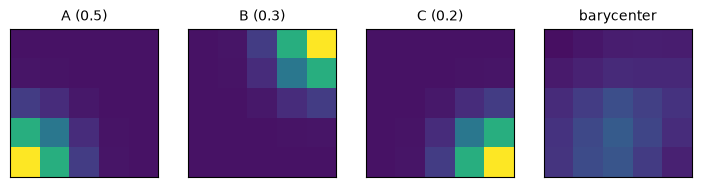

In [12]:
refs, lam = [A, B, C], np.array([0.5, 0.3, 0.2])
nu, J, info = gt.barycenter(G, refs, lam)
print(f"J = {J:.4f}   method = {info['method']}   status = {info['status']} after {info['iters']} iterations")
show([A, B, C, nu], ["A (0.5)", "B (0.3)", "C (0.2)", "barycenter"])

`analysis` runs the other direction: given a target, it finds the weights on the simplex that
make the target a barycenter of the references. On the barycenter we just computed, it returns the
weights we started from.

In [13]:
gt.analysis(G, nu, refs)

array([0.4999998 , 0.29999962, 0.20000058])

Shooting's barycenter is computed by gradient descent. The SOCP solves the same problem to its
global optimum of its discretisation, so it serves as the reference. The two agree up to the SOCP's O(1/N) time error:

In [14]:
nu_socp, J_socp, _ = gt.barycenter(G, refs, lam, method="socp")
print(f"J: shooting {J:.4f}, socp {J_socp:.4f}   max |nu - nu_socp| = {np.abs(nu - nu_socp).max():.1e}")

J: shooting 7.6230, socp 7.6267   max |nu - nu_socp| = 2.9e-03


## Densities that touch zero

Shooting divides by the density, so it cannot take a density that is zero anywhere. When that happens,
the default method emits a `ShootingFallbackWarning` and returns the SOCP's answer instead:

In [15]:
D = np.zeros(G.n)
D[:5] = 1.0  # mass on the bottom row only
D /= D @ G.pi

sol = gt.geodesic(G, A, D)
print(f"W2 = {sol.W2:.4f} from {sol.rho.shape[1] - 1} SOCP time steps")

W2 = 11.5454 from 10 SOCP time steps


/tmp/ipykernel_660565/2386079318.py:5: ShootingFallbackWarning: geodesic: method='shooting' cannot take this data: rhoB is not strictly positive (min 0.000e+00, 20 of 25 nodes at or below the positivity floor). Falling back to method='socp' with its default N=10 (time-discretisation error O(1/N)); pass method='socp' to choose N, or fallback=False to raise instead.
  sol = gt.geodesic(G, A, D)


Pass `fallback=False` to get the error instead. You can also escalate the warning with
`warnings.simplefilter("error", gt.ShootingFallbackWarning)`, or call `method="socp"` directly to
choose `N`.

In [16]:
try:
    gt.geodesic(G, A, D, fallback=False)
except ValueError as e:
    print(e)

rhoB is not strictly positive (min 0.000e+00, 20 of 25 nodes at or below the positivity floor), and method='shooting' needs every density in the interior: its Hamiltonian flow divides by the density. Use method='socp', which is exact for densities supported on part of the graph, or shooting.log_map_mollified for an approximate distance.


## An image example: interpolating digits

A grayscale image is a density on the grid of its pixels. Here are four digits, rendered at 16×16, and
their barycenters for bilinear weights between the corners, in the style of Solomon et al. (2015).
Most pixels are exactly zero, which shooting cannot take, so we call `method="socp"`. Each call
solves only the references with nonzero weight.

We pass `N=12`. At the default `N=10`, one of these twelve solves stops at reduced accuracy
(`optimal_inaccurate`), and the library raises rather than return it, because such an answer can be
far from optimal. A different `N` solves it to optimality.

In [17]:
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure

k = 16
G16 = gt.MarkovGraph(*gt.grid_markov_chain(k))


def glyph(ch):
    fig = Figure(figsize=(1, 1), dpi=k)
    FigureCanvasAgg(fig)
    fig.text(0.5, 0.42, ch, ha="center", va="center", fontsize=80, weight="bold")
    fig.canvas.draw()
    ink = 1 - np.asarray(fig.canvas.buffer_rgba())[..., 0] / 255
    rho = ink[::-1].ravel()  # row 0 at the bottom, as in grid_markov_chain
    return rho / (rho @ G16.pi)


digits = [glyph(c) for c in "0137"]
m = 4
square = {}
t0 = time.perf_counter()
for i in range(m):
    for j in range(m):
        s, t = i / (m - 1), j / (m - 1)
        lam = np.array([(1 - s) * (1 - t), (1 - s) * t, s * (1 - t), s * t])
        used = lam > 0
        if used.sum() == 1:
            square[i, j] = digits[int(np.argmax(lam))]
            continue
        square[i, j], _, _ = gt.barycenter(G16, [d for d, u in zip(digits, used) if u], lam[used], method="socp", N=12)
print(f"{m * m - 4} barycenters in {time.perf_counter() - t0:.0f} s")

12 barycenters in 163 s


Each corner digit gets a color, and each barycenter is drawn in the same weighted mix of those
colors. The color is only a label: what is transported is the intensity. The digits are drawn
centered, on top of one another, so the mass only has to move locally. The in-between shapes
therefore look more like a cross-fade than a slide.

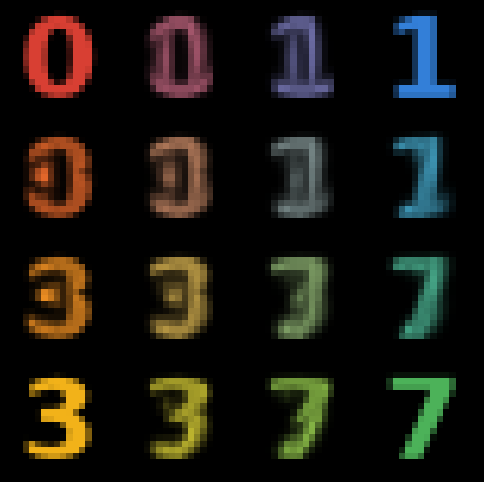

In [18]:
corner_colors = np.array([[0.85, 0.25, 0.2], [0.2, 0.5, 0.85], [0.95, 0.7, 0.1], [0.3, 0.7, 0.35]])
fig, axes = plt.subplots(m, m, figsize=(6, 6), facecolor="black")
for (i, j), rho in square.items():
    s, t = i / (m - 1), j / (m - 1)
    lam = np.array([(1 - s) * (1 - t), (1 - s) * t, s * (1 - t), s * t])
    axes[i, j].imshow((rho / rho.max()).reshape(k, k)[..., None] * (lam @ corner_colors), origin="lower")
    axes[i, j].axis("off")
plt.show()

## Differentiable geodesics

`geodesic` and `transport_cost` take torch tensors. With shooting, gradients flow back to both endpoints,
exactly for the discrete problem the solver solves. Here gradient descent on softmax logits moves a
density, starting from uniform, toward the bump `B` by minimising the transport distance itself:

W: 2.996 at the start, 0.185 after 30 steps


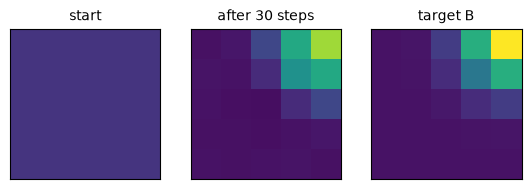

In [19]:
pi = torch.tensor(G.pi)
target = torch.tensor(B)
logits = torch.zeros(G.n, dtype=torch.float64, requires_grad=True)
optimiser = torch.optim.Adam([logits], lr=0.3)
history = []
for step in range(30):
    optimiser.zero_grad()
    rho = torch.softmax(logits, 0) / pi  # a density with respect to pi
    W = gt.transport_cost(G, rho, target)
    W.backward()
    optimiser.step()
    history.append(W.item())
print(f"W: {history[0]:.3f} at the start, {history[-1]:.3f} after {len(history)} steps")
show([np.ones(G.n), (torch.softmax(logits, 0) / pi).detach().numpy(), B], ["start", "after 30 steps", "target B"])

The gradients are first order only, and the SOCP and Sinkhorn methods are not differentiable:
with inputs that require grad they raise, as does shooting where it would otherwise fall back to the
SOCP.

## Below the unified API

The subpackages expose the individual pieces:

- `graphtransport.shooting`: `exp_map`, `log_map`, `integrate_hamiltonian`
- `graphtransport.socp`: `geodesic_socp`, `barycenter_socp`
- `graphtransport.sinkhorn`: the entropic core, with PyTorch and JAX backends for autograd

See [choosing a method](https://dcgentile.github.io/graphtransport-py/methods/) for how the methods compare in cost as the graph grows.